In [2]:
import os
import sys
import json
import csv
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm

In [3]:
import geopandas as gpd
import h3
import h3pandas

from shapely import wkt
from shapely.geometry import shape
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [4]:
# Get the parent directory of the current directory (which is 'notebooks')
# and add it to the system path
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can use absolute imports from the project root
from utils.geometry import get_bearing, get_bearing_label, convert_geometry

In [5]:
import warnings
warnings.filterwarnings('ignore')

### Geo Admin boundaries

In [6]:
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data")

In [7]:
# coasts_gdf = gpd.read_file('natural_earth/ne_10m_coastline.shp')
# admin0_gdf = gpd.read_file('natural_earth/ne_10m_admin_0_boundary_lines_land.shp')
# island_gdf = gpd.read_file('natural_earth/ne_10m_minor_islands_coastline.shp')
# seams_gdf = gpd.read_file('natural_earth/ne_10m_admin_1_seams.shp')

In [8]:
data_fn = os.path.join(DATA_DIR, 'natural_earth\\ne_10m_admin_0_countries_usa.shp')

In [9]:
world_gdf = gpd.read_file(data_fn)

<Axes: >

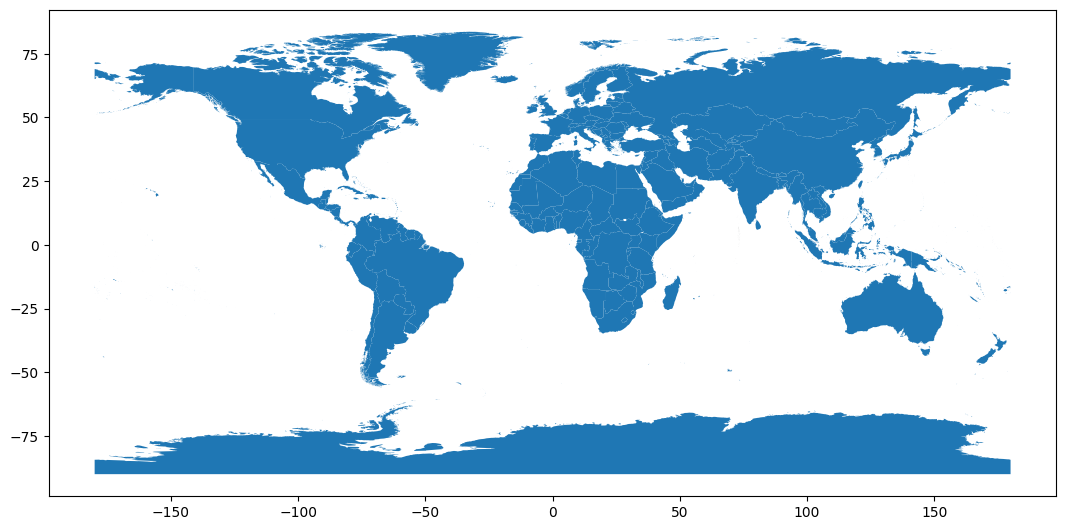

In [10]:
world_gdf.plot(figsize=(13,8))

#### Create a 1km buffer for coastlines in Indonesia

In [19]:
country_gdf = world_gdf[world_gdf['SOV_A3'] == 'USA']

In [20]:
country_gdf = country_gdf.to_crs(3857)

In [21]:
buffered_coasts = country_gdf.buffer(10000)

In [29]:
# buffered_gdf = gpd.GeoDataFrame(geometry=buffered_coasts, crs='EPSG:3857')

In [26]:
buffered_gdf = buffered_gdf.to_crs(4326)

In [30]:
# buffered_gdf.plot(figsize=(13, 8))

### H3

In [31]:
# # Merge all GeoDataFrames
# world_gdf = pd.concat([coasts_gdf, island_gdf], axis=0)
# world_gdf = pd.concat([world_gdf, seams_gdf], axis=0)

In [32]:
# len(coasts_gdf) + len(island_gdf) + len(seams_gdf)

In [33]:
limit_cols = []
for col in world_gdf.columns:
    null_df = world_gdf[world_gdf[col].isna()]
    if col.startswith('NAME') or col.startswith('ADM0') or col.startswith('FCLASS') or col.startswith('BRK') or col.startswith('WOE') or col.startswith('WB') or col.startswith('ISO_N3') or col.startswith('ISO_A2_EH'):
        pass
    elif 'LABEL' in col or 'ZOOM' in col or 'MAPCOLOR' in col:
        pass
    elif col in ['FIPS_10', 'FIPS_10', 'ISO_A3_EH', 'INCOME_GRP', 'SUBUNIT', 'FORMAL_EN', 'GEOUNIT', 'GU_A3', 'SU_A3', 'UN_A3', 'TLC', 'TYPE', 'LEVEL', 'featurecla', 'scalerank', 'GEOU_DIF', 'SU_DIF', 'HOMEPART', 'BRK_DIFF', 'POSTAL', 'ABBREV', 'TINY']:
        pass
    elif null_df.empty:
        limit_cols.append(col)
    elif len(null_df) < 0.1 * len(world_gdf):
        limit_cols.append(col)

In [34]:
limit_cols

['SOVEREIGNT',
 'SOV_A3',
 'ADMIN',
 'POP_EST',
 'POP_RANK',
 'POP_YEAR',
 'GDP_MD',
 'GDP_YEAR',
 'ECONOMY',
 'ISO_A2',
 'ISO_A3',
 'CONTINENT',
 'REGION_UN',
 'SUBREGION',
 'REGION_WB',
 'LONG_LEN',
 'ABBREV_LEN',
 'NE_ID',
 'WIKIDATAID',
 'geometry']

In [35]:
world_gdf = world_gdf.filter(limit_cols)

In [36]:
world_gdf

,SOVEREIGNT,SOV_A3,ADMIN,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,ISO_A2,ISO_A3,CONTINENT,REGION_UN,SUBREGION,REGION_WB,LONG_LEN,ABBREV_LEN,NE_ID,WIKIDATAID,geometry
0,Indonesia,IDN,Indonesia,270625568.0,17,2019,1119190,2019,4. Emerging region: MIKT,ID,IDN,Asia,Asia,South-Eastern Asia,East Asia & Pacific,9,5,1159320845,Q252,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Malaysia,MYS,Malaysia,31949777.0,15,2019,364681,2019,6. Developing region,MY,MYS,Asia,Asia,South-Eastern Asia,East Asia & Pacific,8,6,1159321083,Q833,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Chile,CHL,Chile,18952038.0,14,2019,282318,2019,5. Emerging region: G20,CL,CHL,South America,Americas,South America,Latin America & Caribbean,5,5,1159320493,Q298,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Bolivia,BOL,Bolivia,11513100.0,14,2019,40895,2019,5. Emerging region: G20,BO,BOL,South America,Americas,South America,Latin America & Caribbean,7,7,1159320439,Q750,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Peru,PER,Peru,32510453.0,15,2019,226848,2019,5. Emerging region: G20,PE,PER,South America,Americas,South America,Latin America & Caribbean,4,4,1159321163,Q419,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,Spratly Islands,PGA,Spratly Islands,100.0,1,2017,0,2016,7. Least developed region,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,15,11,1159321165,Q43296,"MULTIPOLYGON (((115.3672 10.23749, 115.36598 1..."
248,France,FR1,Clipperton Island,0.0,1,2019,0,2016,7. Least developed region,-99,-99,Seven seas (open ocean),Americas,Central America,Latin America & Caribbean,17,7,1159320635,Q161258,"POLYGON ((-109.21203 10.30268, -109.21036 10.2..."
249,China,CH1,Macao S.A.R,640445.0,11,2019,53859,2019,6. Developing region,MO,MAC,Asia,Asia,Eastern Asia,East Asia & Pacific,5,4,1159320475,Q14773,"MULTIPOLYGON (((113.5586 22.16303, 113.56943 2..."
250,Australia,AU1,Ashmore and Cartier Islands,0.0,1,2019,0,2019,7. Least developed region,-99,-99,Oceania,Oceania,Australia and New Zealand,East Asia & Pacific,27,7,1159320353,Q133888,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."


In [37]:
country_lookup = {}

In [38]:
grp_by_admin = world_gdf[['SOV_A3', 'WIKIDATAID']].groupby('SOV_A3').agg('count')

In [39]:
grp_by_admin = grp_by_admin.reset_index()

In [40]:
# grp_by_admin[grp_by_admin['WIKIDATAID'] > 1]
multi_sov = grp_by_admin[grp_by_admin['WIKIDATAID'] > 1].SOV_A3.to_list()

In [41]:
len(world_gdf['WIKIDATAID'].drop_duplicates().to_list()) == len(world_gdf)

True

In [42]:
for country in world_gdf.SOV_A3.drop_duplicates().to_list():

    tmp_gdf = world_gdf[(world_gdf['SOV_A3'] == country)]
    try:
    
        if country in multi_sov:
            sub_list = tmp_gdf.ADMIN.drop_duplicates().to_list()
            for sub in sub_list:
                tmp_tmp_gdf = tmp_gdf[tmp_gdf['ADMIN'] == sub]
                tmp_hex_df = tmp_tmp_gdf.h3.polyfill(5, explode=True)
                subname = sub.lower().replace(' ', '_')
                country_key = f"{country}_{subname}"
                country_lookup[country_key] = tmp_hex_df.h3_polyfill.drop_duplicates().to_list()
        else:
            tmp_hex_df = tmp_gdf.h3.polyfill(5, explode=True)
            country_lookup[country] = tmp_hex_df.h3_polyfill.drop_duplicates().to_list()
    except:
        country_lookup[country] = []


In [43]:
country_verbose_lookup = {}
for country in world_gdf.ADMIN.drop_duplicates().to_list():

    tmp_gdf = world_gdf[(world_gdf['ADMIN'] == country)]
    try:
        tmp_hex_df = tmp_gdf.h3.polyfill(5, explode=True)
        country_verbose_lookup[country] = tmp_hex_df.h3_polyfill.drop_duplicates().to_list()
    except:
        country_verbose_lookup[country] = []


In [44]:
len(country_lookup)

250

In [45]:
len(country_verbose_lookup)

250

In [46]:
with open(os.path.join(DATA_DIR, 'opto_index\\country_code_3_h5_ids.json'), 'w') as fw:
    json_data = json.dumps(country_lookup)
    fw.write(json_data)

In [48]:
with open(os.path.join(DATA_DIR, 'opto_index\\country_name_h5_ids.json'), 'w') as fw:
    json_data = json.dumps(country_verbose_lookup)
    fw.write(json_data)